# Case Study 2: Repuragent as an assistant for COVID19 repurposing screening project

This COVID-19 case study is a retrospective analysis to demonstrate how **Repuragent** can assist experimental scientists throughout the research workflow, including data streamlining, analysis, and confounder detection.

The original study was conducted by [Elin et al.](https://drugrepocentral.scienceopen.com/hosted-document?doi=10.14293/iDR.25.010EA). This notebook focuses on analyzing the outputs generated by Repuragent. To see the agent full run please visit:
[https://repuragent.serve.scilifelab.se](https://repuragent.serve.scilifelab.se)

---

## Notebook Structure

This notebook includes four parts:
* **Part 1:** Data preparation, processing, and aggregation
* **Part 2:** Analysis of the primary screen
* **Part 3:** Analysis of the validation screen
* **Part 4:** Analysis of the final selection


# Part 1: Data preparation, processing, and aggregation

In [1]:
import pandas as pd 
from tqdm import tqdm
import matplotlib.pyplot as plt
from COVID_19_utils import *

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Nature-style global settings
COLORS = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
sns.set_theme(style="ticks")


In [ ]:
tqdm.pandas()

# Get chemBL for drug list
df = pd.read_csv('raw_data/morphology_infectivity_VeroE6.csv')
df['chembl_id'] = df['compound_name'].progress_apply(get_chembl_id)

# Flag initial hits, total 150 hits
df = df.sort_values(['morphology score'], ascending=False).reset_index(drop=True)
df["is_CP_hit"] = False
df.loc[:150, "is_CP_hit"] = True
df.to_csv("raw_data/COVID_19_data.csv", index = False)

# Filter columns for agent data input
df_for_agent = df[['compound_name', 'chembl_id']]
df_for_agent = df_for_agent.sample(n=len(df_for_agent))
df_for_agent.to_csv('processed_data/COVID19_agent.csv', index = False)

In [ ]:
df = pd.read_csv('raw_data/COVID_19_data.csv')

# Flag combine hits from experiments, total ±300 hits
df_324_hit = pd.read_csv('raw_data/morphology_infectivity_A549-ACE2.csv')
df['is_324_hit'] = df['compound_name'].isin(df_324_hit['compound_name'])
df.drop_duplicates('compound_name', inplace = True)

# Flag 74 hits
df_74_hit = pd.read_csv('raw_data/74_hit.csv')
df_74_hit = df_74_hit.drop('batch_id', axis = 1)
df_74_hit.columns = ['top_74_rank', 'compound_name']
df = df.merge(df_74_hit, on ='compound_name', how = 'outer')
df['is_74_hit'] = df['compound_name'].isin(df_74_hit['compound_name'])
df.dropna(subset=['Concentration uM', 'Cell model', 'is_CP_hit', 'is_324_hit'],inplace=True)

# Flag 5 hits
df_5_hit = pd.read_csv('raw_data/5_hit.csv')
df['is_5_hit'] = df['compound_name'].isin(df_5_hit['compound_name'])

# Export data
df.to_csv('processed_data/COVID_19_processed.csv', index= False)


In [ ]:
df_raw = pd.read_csv('raw_data/R4A_BenevolentAI_COVID.csv')
df_raw = df_raw[['compound_name','HIT_antiviral_AB_Y/N','HIT_CPE_Y/N','HIT_cellpaiting_Y/N']]
df_raw = df_raw.sort_values('compound_name').reset_index(drop=True)

df = pd.read_csv('processed_data/COVID_19_processed.csv')
df = df.sort_values('compound_name').reset_index(drop=True)

In [ ]:
df_stack = pd.concat([df, df_raw.drop(columns='compound_name')], axis=1)
df_stack['is_AB_hit'] = df_stack['HIT_antiviral_AB_Y/N'] == 'Y'
df_stack['is_CPE_hit'] = df_stack['HIT_CPE_Y/N'] == 'Y'
df_stack['is_CP_hit'] = df_stack['HIT_cellpaiting_Y/N'] == 'Y'

df_stack.to_csv('processed_data/COVID_19_total.csv', index= False)
df_stack[['compound_name', 'chembl_id', 'is_AB_hit', 'infection rate (%)']].to_csv('processed_data/AB_experimental_data.csv', index=False)
df_stack[['compound_name', 'chembl_id', 'morphology score', 'is_CP_hit']].to_csv('CP_experimental_data.csv', index=False)


df_cpe = pd.read_csv('raw_data/CPE_assay.csv')
df_cpe = df_cpe.drop(['Non_infected cell viability(%)', "Duplicated"], axis=1)
df_cpe.columns = ['compound_name', 'Concentration CPE (nM)', 'Inhibition of cytopathicity (%)']
df_cpe = df_cpe.drop_duplicates('compound_name')

df_merge = df_stack.merge(df_cpe, on = 'compound_name', how='left')
df_merge[['compound_name', 'chembl_id', 'is_CPE_hit', 'Concentration CPE (nM)', 'Inhibition of cytopathicity (%)']].to_csv('processed_data/CPE_experimental_data.csv', index=False)
df_merge.to_csv('processed_data/COVID_19_total.csv', index= False)

# Part 2: Analysis of the primary screen

Alongside the agent, we draw a **naive fixed-rule baseline**, a simple aggregate-and-rank control requested as a reference point. It is computed separately in `naive_baseline.ipynb` from the same three per-assay input files the agent received (`CP_experimental_data.csv`, `AB_experimental_data.csv`, `CPE_experimental_data.csv`), using equal-weight z-score aggregation with no weighting, dose modelling, or confounder handling, and loaded here from `naive_scoring/primary_screen_naive.csv`. The single-assay curves (CP / CPE / AB) additionally show what selecting on any one experimental readout alone would achieve.

In [11]:
# Load data for Repuragent running with pre-defined threshold
df_agent = pd.read_csv('agent_as_assistant/primary_screen_constrains/integrated_ranking.csv')
df_agent.drop_duplicates('chembl_id',inplace=True)
df_agent = df_agent[['chembl_id','rank']]

# Load data for Repuragent running without pre-defined threshold
df_agent_2 = pd.read_csv('agent_as_assistant/primary_screen/integrated_ranked_compounds.csv')
df_agent_2.drop_duplicates('chembl_id',inplace=True)
df_agent_2 = df_agent_2[['chembl_id','rank']]

In [12]:
df = pd.read_csv('processed_data/COVID_19_total.csv')
df.drop_duplicates('chembl_id', inplace=True)
df.drop_duplicates('compound_name', inplace=True)

df_merge = df.merge(df_agent, on='chembl_id', how = 'inner', suffixes=['exp','constrain']).merge(df_agent_2, on='chembl_id', how = 'inner', suffixes=['_constrain','_no_constrain'])

# Attach the naive fixed-rule baseline scores (computed in naive_baseline.ipynb)
df_naive = pd.read_csv('naive_scoring/primary_screen_naive.csv')
df_merge = df_merge.merge(df_naive[['compound_name', 'naive_composite']], on='compound_name', how='left')
df_merge

,compound_name,Concentration uM,morphology score,infection rate (%),Cell model,chembl_id,is_CP_hit,is_324_hit,top_74_rank,is_74_hit,...,HIT_antiviral_AB_Y/N,HIT_CPE_Y/N,HIT_cellpaiting_Y/N,is_AB_hit,is_CPE_hit,Concentration CPE (nM),Inhibition of cytopathicity (%),rank_constrain,rank_no_constrain,naive_composite
0,(-)-Huperzine A,10.00,-0.12,108.0,Vero E6,CHEMBL395280,False,False,NaN,False,...,N,N,N,False,False,8.33,2.10,4052,4054,-0.063005
1,"1,12-Besm",0.83,0.31,80.5,Vero E6,CHEMBL18794,False,False,NaN,False,...,N,N,N,False,False,10000.00,11.44,357,279,0.132497
2,"1,2,3,4,5,6-hexabromocyclohexane",10.00,0.42,85.0,Vero E6,CHEMBL444236,False,False,NaN,False,...,N,N,N,False,False,10000.00,9.07,337,315,0.122416
3,"1,3-dipropyl-8-phenylxanthine",10.00,0.10,103.5,Vero E6,CHEMBL158507,False,False,NaN,False,...,N,N,N,False,False,10000.00,-1.61,3581,4069,-0.023683
4,"1,4-butanediol",10.00,0.02,105.0,Vero E6,CHEMBL171623,False,False,NaN,False,...,N,N,N,False,False,833.33,0.26,3985,4033,-0.036802
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5154,zosuquidar,0.83,0.03,108.5,Vero E6,CHEMBL3907347,False,False,NaN,False,...,N,N,N,False,False,8.33,1.65,3923,3628,-0.034785
5155,zotarolimus,0.83,-0.29,119.0,Vero E6,CHEMBL219410,False,False,NaN,False,...,N,N,N,False,False,10000.00,1.71,5012,5022,-0.144534
5156,zotepine,0.83,0.06,106.5,Vero E6,CHEMBL285802,False,False,NaN,False,...,N,N,N,False,False,100.00,4.34,2243,1813,-0.010947
5157,zoxazolamine,10.00,0.01,97.0,Vero E6,CHEMBL472566,False,False,NaN,False,...,N,N,N,False,False,1.00,0.87,2692,2554,-0.013682


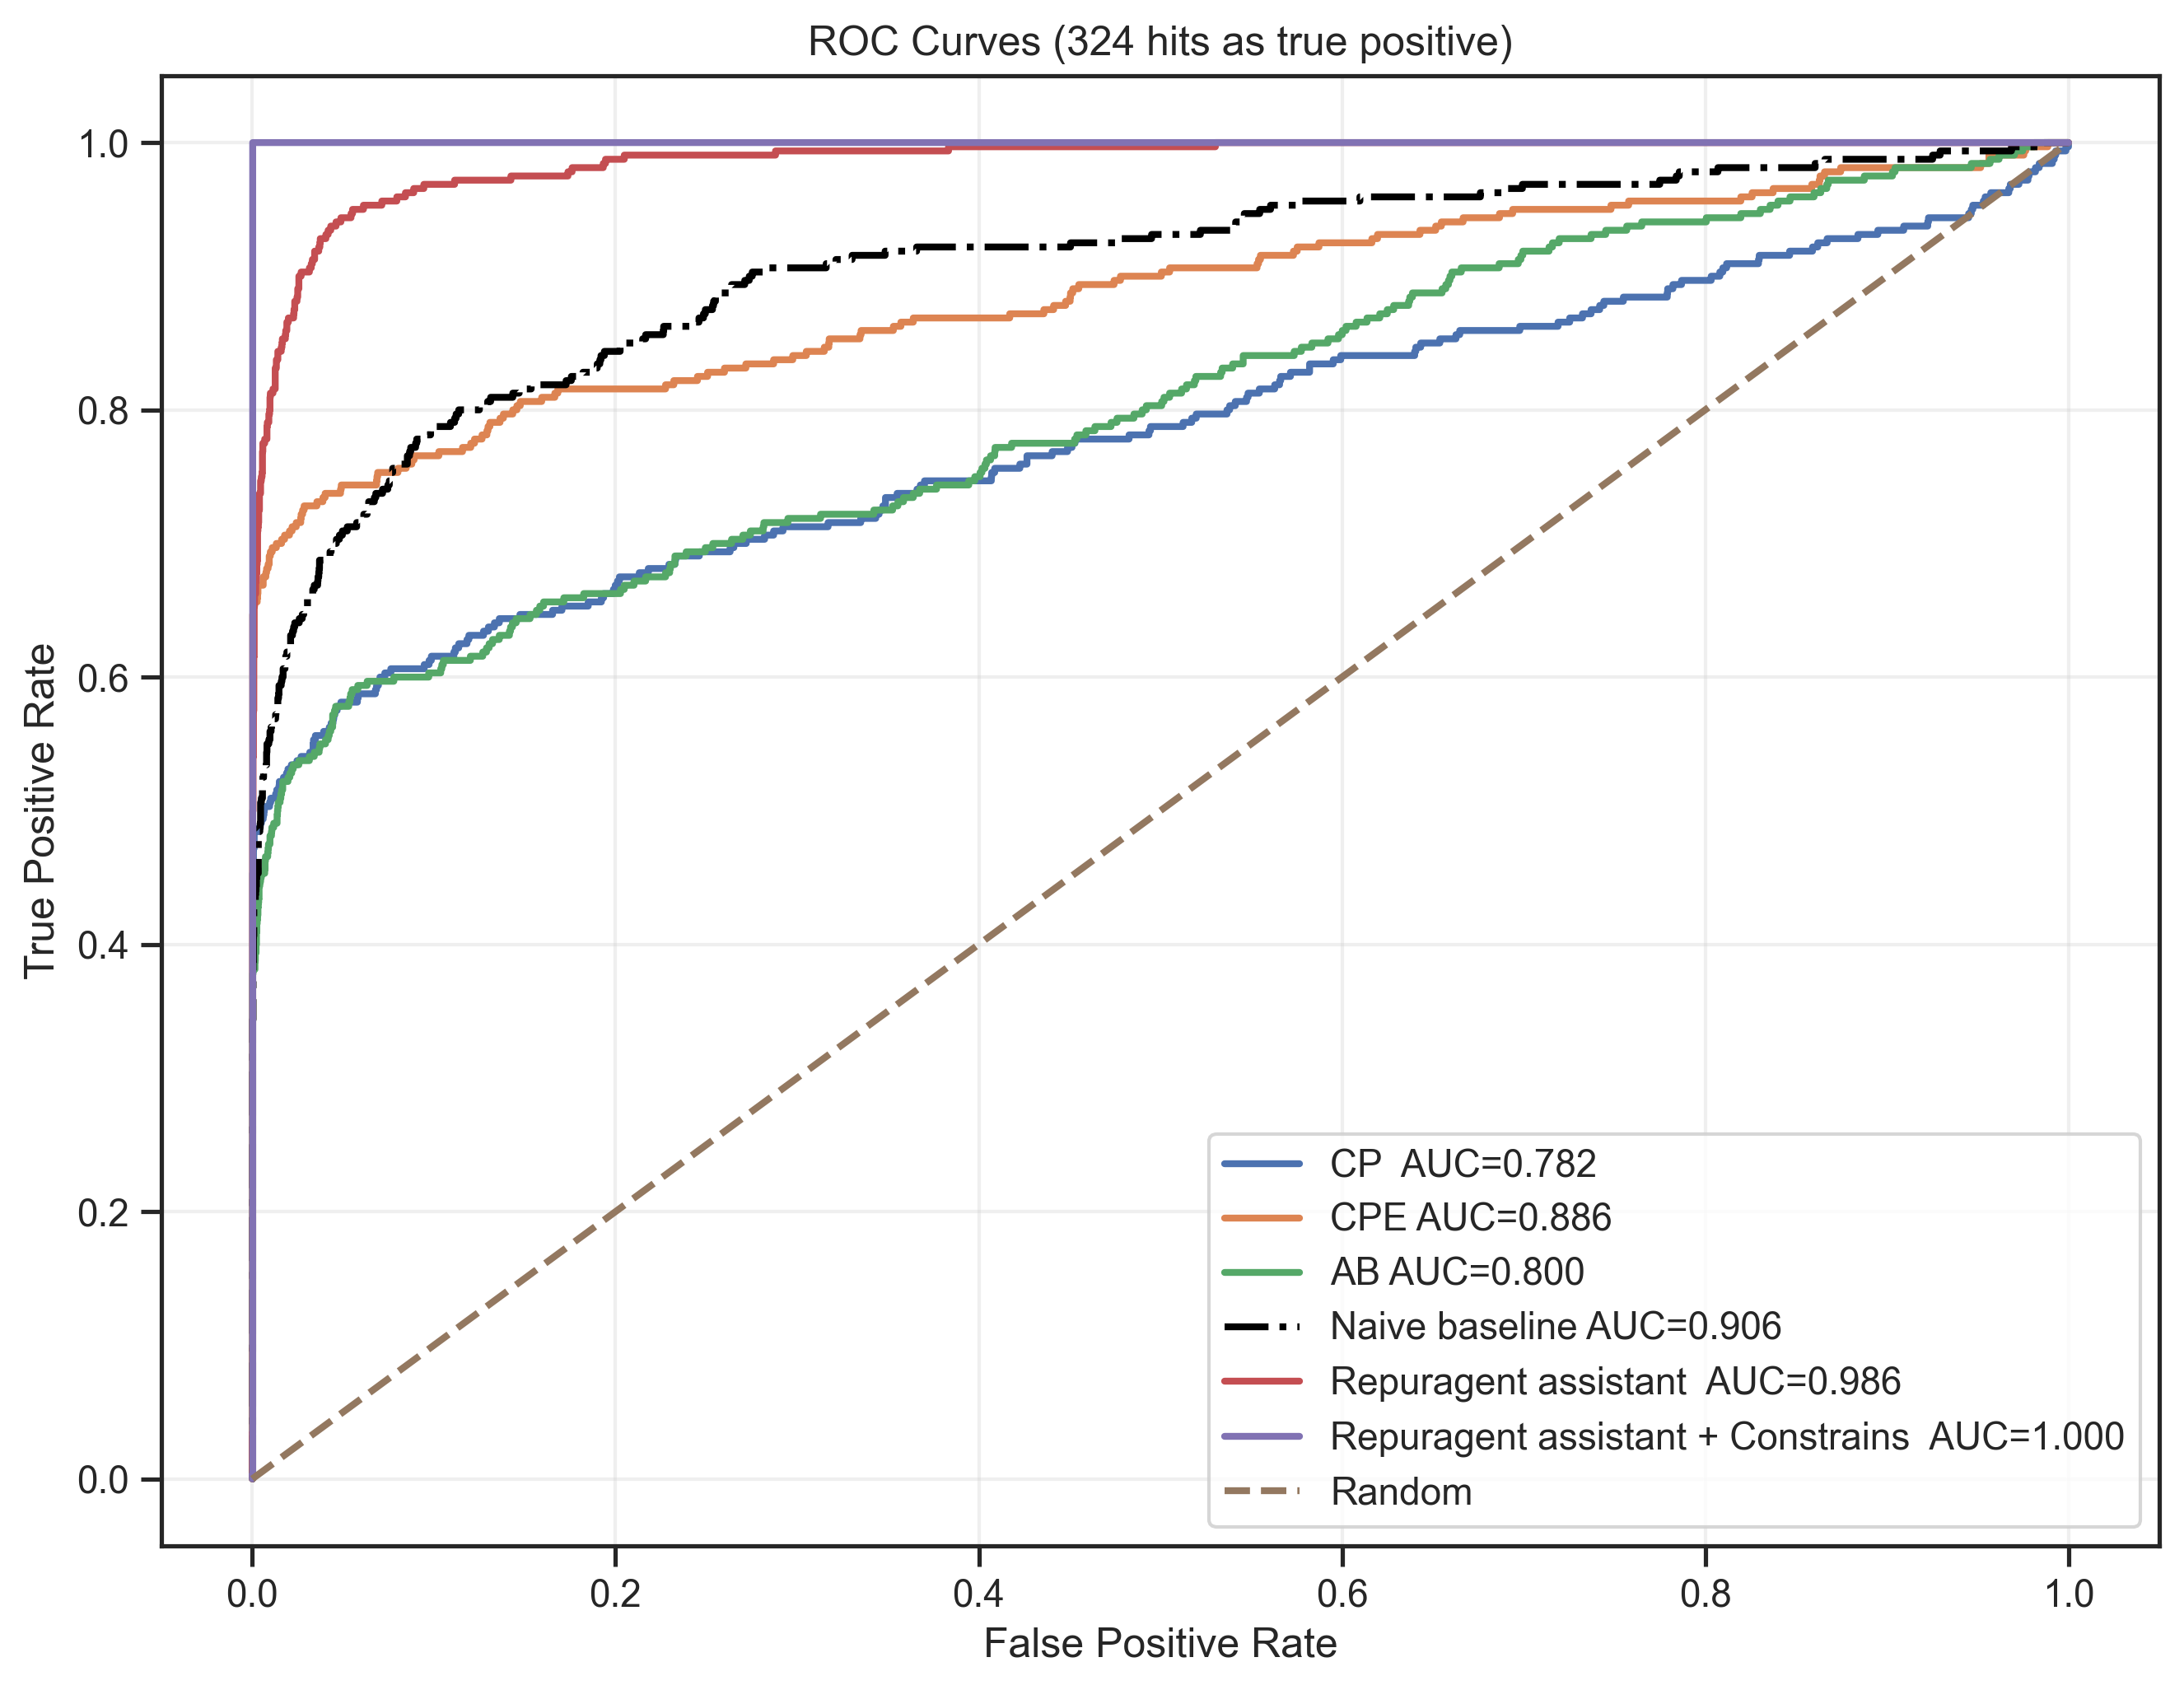

In [13]:
# Define columns
hit_col = "is_324_hit"

col_morph = "morphology score"                 # CP experiment score column
col_cpe   = "Inhibition of cytopathicity (%)"  # CPE experiment score column
col_ab    = "infection rate (%)"               # AB experiment score column
col_naive = "naive_composite"

rank_agent_no_constrain = 'rank_no_constrain'
rank_agent_constrain = 'rank_constrain'

# Naive fixed-rule baseline: `naive_composite` is loaded from
# naive_scoring/primary_screen_naive.csv (produced by naive_baseline.ipynb).

# ROC calculation
fpr_cp,  tpr_cp,  auc_cp  = roc_from_score(df_merge, col_morph, hit_col, ascending=False)
fpr_cpe, tpr_cpe, auc_cpe = roc_from_score(df_merge, col_cpe,   hit_col, ascending=False)
fpr_ab,  tpr_ab,  auc_ab  = roc_from_score(df_merge, col_ab,    hit_col, ascending=True)
fpr_naive, tpr_naive, auc_naive = roc_from_score(df_merge, col_naive, hit_col, ascending=False)
fpr_r_agent,  tpr_r_agent,  auc_r_agent  = roc_from_score(df_merge, rank_agent_no_constrain,  hit_col, ascending = True)
fpr_r_agent_con,  tpr_r_agent_con,  auc_r_agent_con  = roc_from_score(df_merge, rank_agent_constrain,  hit_col, ascending = True)


# Plot
plt.figure(figsize=(9, 7))

plt.plot(fpr_cp,   tpr_cp,   lw=2, label=f'CP  AUC={auc_cp:.3f}')
plt.plot(fpr_cpe,  tpr_cpe,  lw=2, label=f'CPE AUC={auc_cpe:.3f}')
plt.plot(fpr_ab,   tpr_ab,   lw=2, label=f'AB AUC={auc_ab:.3f}')

plt.plot(fpr_naive, tpr_naive, lw=2, ls='-.', color='black', label=f'Naive baseline AUC={auc_naive:.3f}')
plt.plot(fpr_r_agent,  tpr_r_agent,  lw=2, label=f'Repuragent assistant  AUC={auc_r_agent:.3f}')
plt.plot(fpr_r_agent_con,  tpr_r_agent_con,  lw=2, label=f'Repuragent assistant + Constrains  AUC={auc_r_agent_con:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, label='Random')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (324 hits as true positive)")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Part 3: Analysis of the validation screen


A **naive fixed-rule baseline** is also drawn for the validation screen. It is computed separately in `naive_baseline.ipynb` from the two raw validation input files (`validatation_experiements.xlsx`, `phospholipidosis_raw.xlsx`), averaging each readout over all tested concentrations per compound and combining morphology rescue, infection rate, and 24h DIPL with equal-weight z-scores. All were loaded from `naive_scoring/validation_screen_naive.csv`. 

In [14]:
# Agent output for the validation screen (input files: validatation_experiements.xlsx, phospholipidosis_raw.xlsx). 
# We keep only the agent's final ranking here.
df_agent = pd.read_csv('agent_as_assistant/validation_screen/ranking_output.csv')
df_agent.drop_duplicates('chembl_id',inplace=True)
df_agent = df_agent[['chembl_id','ranking_position']]

In [15]:
df = pd.read_csv('processed_data/COVID_19_total.csv')
df = df[df['is_324_hit']]
df.drop_duplicates('chembl_id', inplace=True)
df.drop_duplicates('compound_name', inplace=True)

df_merge = df.merge(df_agent, on='chembl_id', how = 'inner')

# Attach the naive fixed-rule baseline scores (computed in naive_baseline.ipynb)
df_naive = pd.read_csv('naive_scoring/validation_screen_naive.csv')
df_merge = df_merge.merge(df_naive[['compound_name', 'naive_composite']], on='compound_name', how='left')
df_merge

,compound_name,Concentration uM,morphology score,infection rate (%),Cell model,chembl_id,is_CP_hit,is_324_hit,top_74_rank,is_74_hit,is_5_hit,HIT_antiviral_AB_Y/N,HIT_CPE_Y/N,HIT_cellpaiting_Y/N,is_AB_hit,is_CPE_hit,Concentration CPE (nM),Inhibition of cytopathicity (%),ranking_position,naive_composite
0,10-DEBC,0.83,0.33,93.0,Vero E6,CHEMBL1398474,False,True,52.0,True,False,N,Y,N,False,True,10000.00,40.87,84,-0.140451
1,17-hydroxyprogesterone-caproate,10.00,0.52,85.5,Vero E6,CHEMBL1200848,True,True,NaN,False,False,N,N,Y,False,False,10000.00,5.84,37,-0.060528
2,2-pyridylethylamine,10.00,0.07,104.0,Vero E6,CHEMBL32813,False,True,NaN,False,False,N,Y,N,False,True,8.33,24.26,228,-0.297629
3,3'-fluorobenzylspiperone,0.83,0.33,103.0,Vero E6,CHEMBL137648,False,True,NaN,False,False,N,Y,N,False,True,10000.00,71.66,138,-0.096409
4,"3,4-methylenedioxy-beta-nitrostyrene",10.00,0.58,41.0,Vero E6,CHEMBL596380,True,True,NaN,False,False,Y,N,Y,True,False,10000.00,7.29,293,-0.090025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,triflupromazine,10.00,0.46,56.0,Vero E6,CHEMBL570,False,True,NaN,False,False,Y,N,N,True,False,833.33,1.78,141,-0.027665
316,tyrphostin-AG-1478,10.00,-0.32,117.5,Vero E6,CHEMBL7917,False,True,63.0,True,False,N,Y,N,False,True,10000.00,17.87,86,-0.076780
317,tyrphostin-AG-835,10.00,0.49,78.0,Vero E6,CHEMBL261557,True,True,NaN,False,False,N,N,Y,False,False,10000.00,3.48,104,-0.272200
318,wiskostatin,0.83,0.15,109.5,Vero E6,CHEMBL1476463,False,True,NaN,False,False,N,Y,N,False,True,10000.00,57.26,235,-0.239844


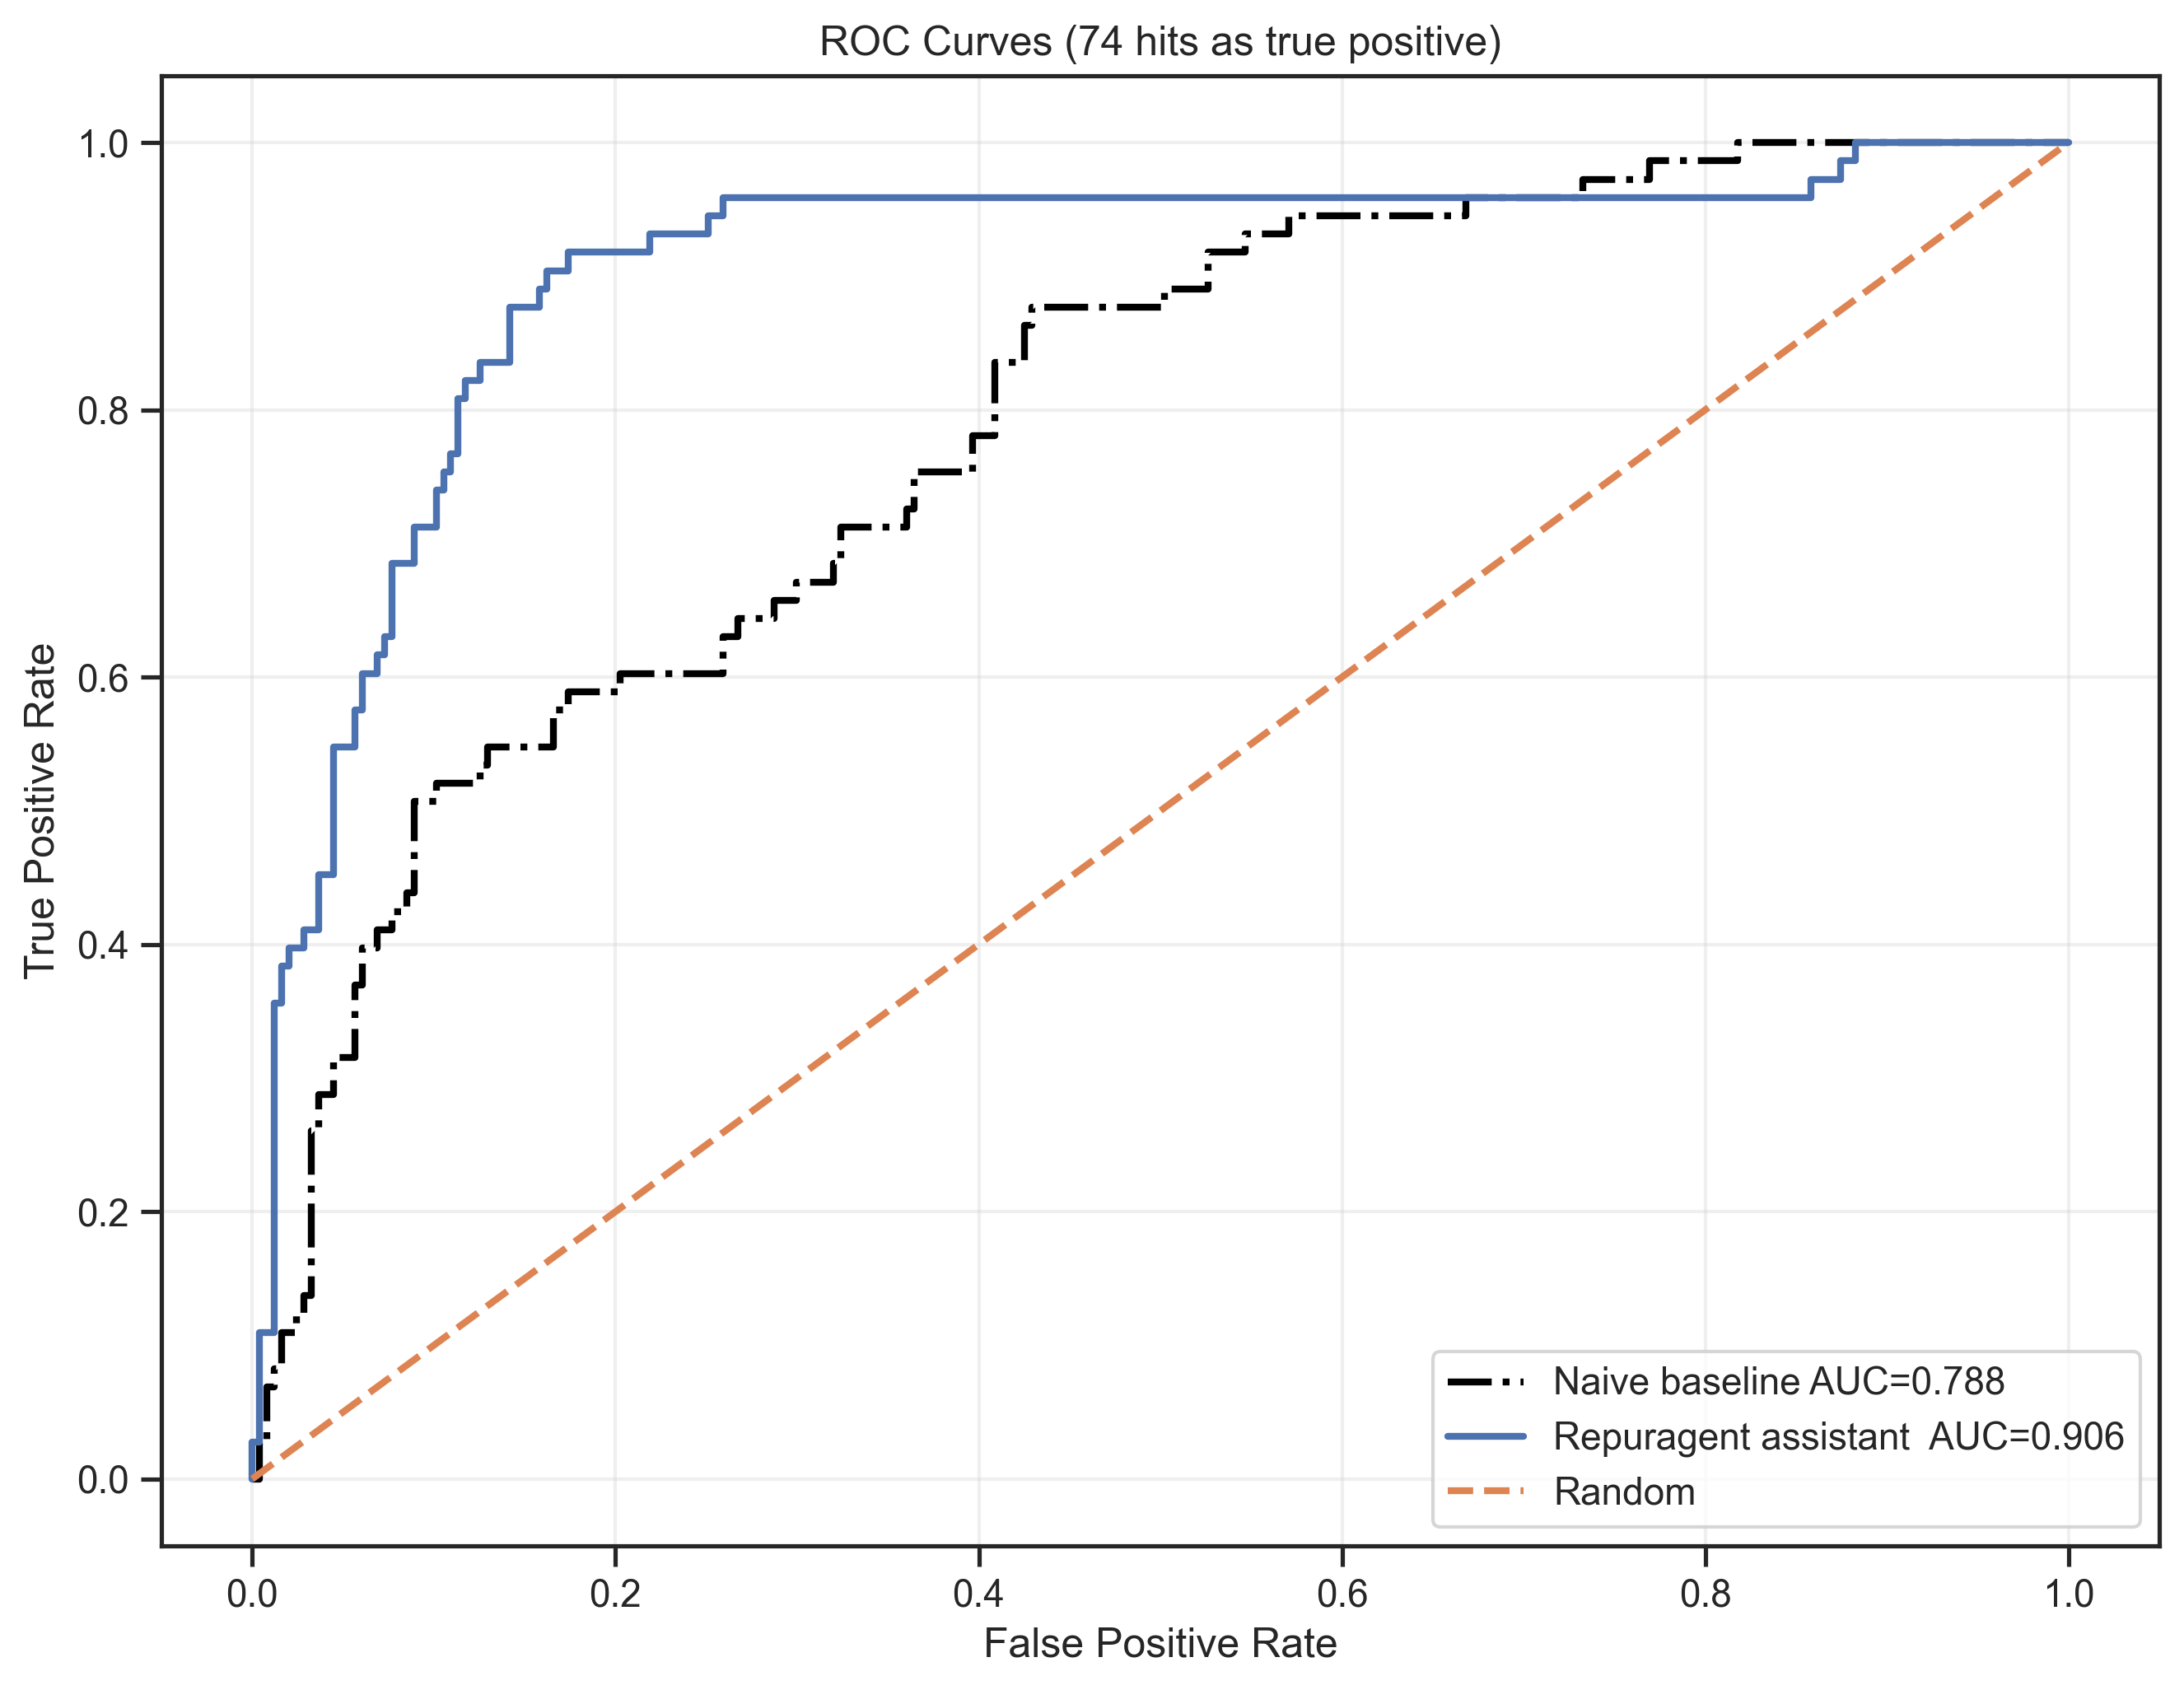

In [17]:
# Define columns
hit_col = "is_74_hit"
rank_agent = 'ranking_position'
col_naive = "naive_composite"

# Naive fixed-rule baseline: `naive_composite` is loaded from
# naive_scoring/validation_screen_naive.csv (produced by naive_baseline.ipynb).

# ROC calculation
fpr_r_agent, tpr_r_agent, auc_r_agent = roc_from_rank(df_merge, rank_agent, hit_col)
fpr_naive,   tpr_naive,   auc_naive   = roc_from_score(df_merge, col_naive, hit_col, ascending=False)

# Plot
plt.figure(figsize=(9, 7))
plt.plot(fpr_naive,   tpr_naive,   lw=2, ls='-.', color='black', label=f'Naive baseline AUC={auc_naive:.3f}')
plt.plot(fpr_r_agent, tpr_r_agent, lw=2, label=f'Repuragent assistant  AUC={auc_r_agent:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, label='Random')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (74 hits as true positive)")
plt.grid(alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


# Part 4: Analysis of the final selection

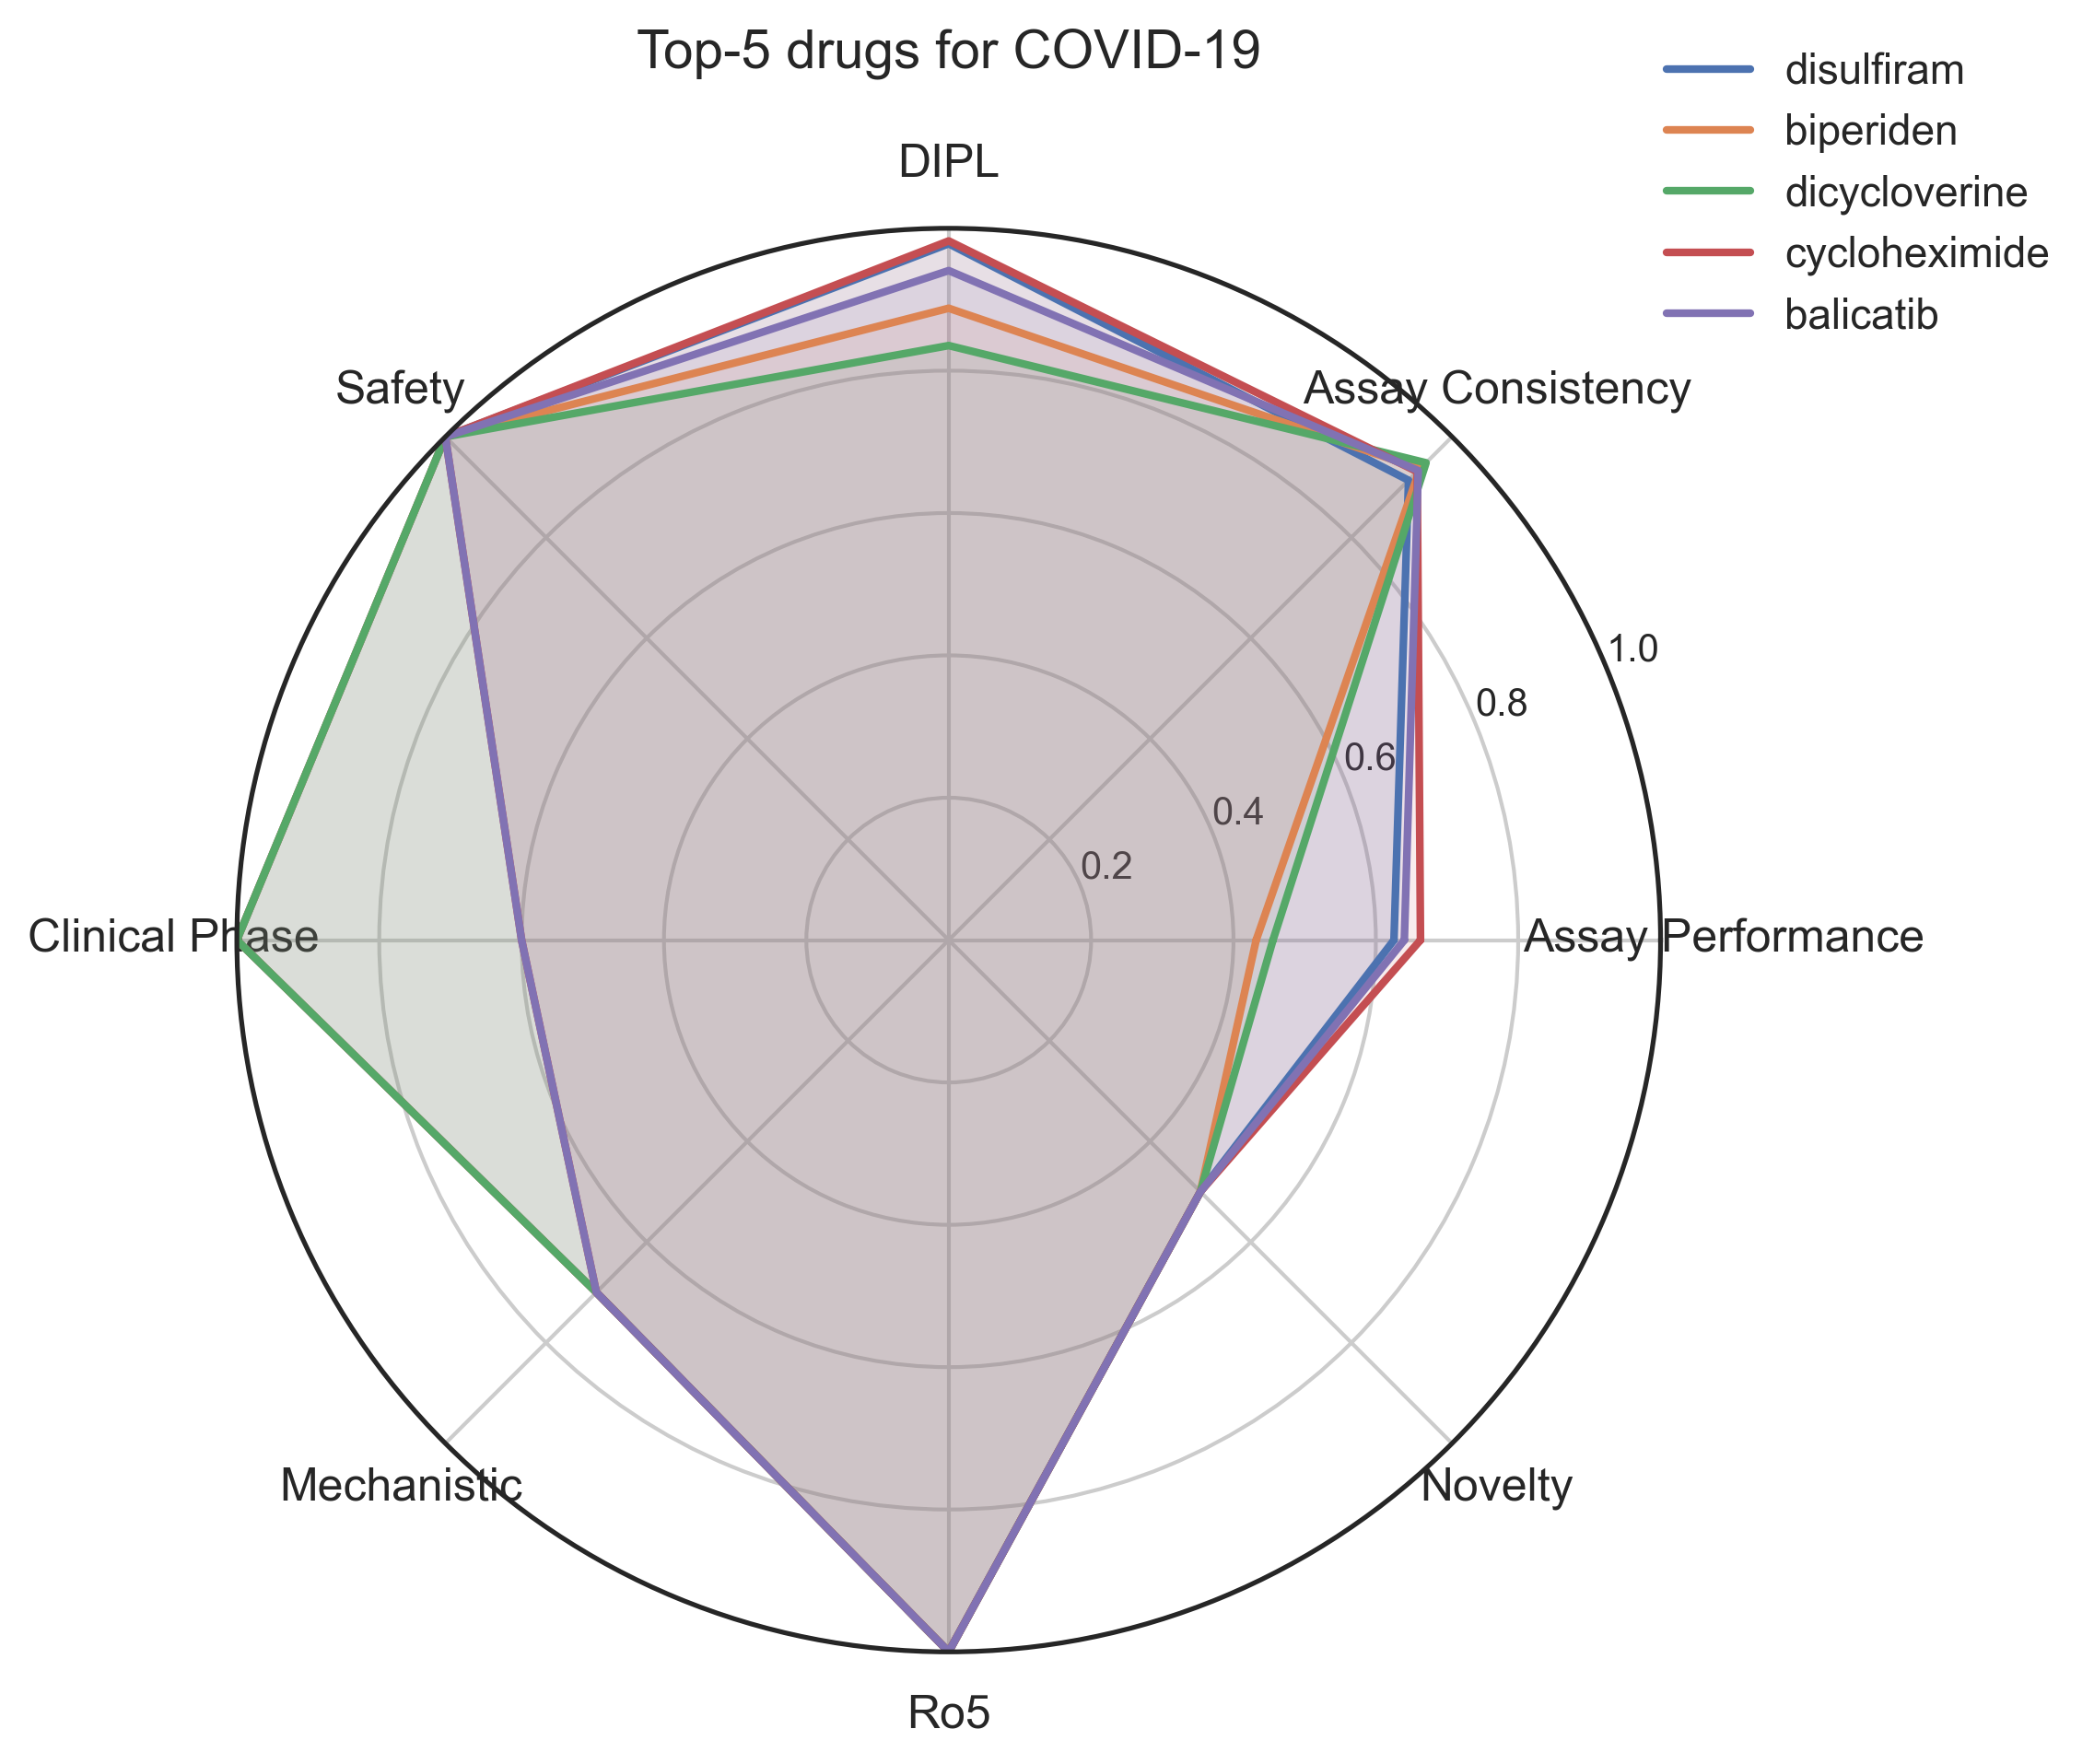

In [18]:
# Load data
df = pd.read_csv("agent_as_assistant/final_validation/74_hits_ranked.csv")
top5 = df.head(5).copy()

# Define columns
cols = [
    "A_assay_efficacy",
    "B_consistency",
    "C_PLD",
    "D_safety_proxy",
    "E_clinical",
    "F_mechanism_proxy",
    "G_druglikeness",
    "H_novelty",
]
labels = ["Assay Performance", "Assay Consistency", "DIPL", "Safety", "Clinical Phase", "Mechanistic", "Ro5", "Novelty"]

vals = top5[cols].astype(float).values
names = top5["compound_name"].astype(str).values

# Plot
N = len(cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

for i, name in enumerate(names):
    data = vals[i].tolist()
    data += data[:1]
    ax.plot(angles, data, linewidth=2, label=name)
    ax.fill(angles, data, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2","0.4","0.6","0.8","1.0"], fontsize=10)

ax.set_title("Top-5 drugs for COVID-19", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15), frameon=False)

plt.tight_layout()
plt.show()
